# Clonamos el repositorio con los modelos y herramientas

In [1]:
!git clone https://github.com/dannasalazar11/Msc_thesis.git

Cloning into 'Msc_thesis'...
remote: Enumerating objects: 488, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 488 (delta 38), reused 0 (delta 0), pack-reused 427 (from 1)
Receiving objects: 100% (488/488), 50.49 MiB | 41.86 MiB/s, done.
Resolving deltas: 100% (315/315), done.


In [2]:
import sys
sys.path.append('/kaggle/working/Msc_thesis')

from gmrrnet_adhd.utils import get_segmented_data
#from tensorflow.keras.mixed_precision import set_global_policy
#set_global_policy('mixed_float16')


import tensorflow as tf
import numpy as np
import random
import os

# Establecer semilla
seed = 42

# Semillas para módulos principales
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

2025-11-05 23:00:35.130423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762383635.523838      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762383635.637278      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Importar base de datos segmentada (Segmentos de 4 seg con translape del 50%, es decir, de 2 seg)

In [3]:
X, y, sbjs = get_segmented_data()
X.shape, y.shape, len(sbjs)

((8213, 19, 512), (8213, 2), 8213)

# Importamos el modelo y definimos los hiperparámetros

In [4]:
import os

import pickle

with open("/kaggle/input/ieee-tdah-control-database/folds.pkl", "rb") as f:
    folds = pickle.load(f)

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Concatenate, Input, Reshape, Flatten, Dense, Dropout, Activation, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.losses import Loss
from keras_nlp.layers import TransformerEncoder

@tf.keras.utils.register_keras_serializable()
class GaussianKernelLayer(Layer):
    def __init__(self, **kwargs):
        super(GaussianKernelLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # No es necesario agregar sigma como un peso aquí
        super(GaussianKernelLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs ahora será una lista o tupla: [x, sigma]
        x, sigma = inputs  # Asumimos que sigma viene como entrada junto con los datos
        
        # inputs shape: (N, C, T, F)
        N, C, T, F = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Reshape the input to (N*F, C, T)
        x = tf.transpose(x, perm=(0,3,1,2))  # (N,F,C,T)
        x_reshaped = tf.reshape(x, (N*F, C, T))
        
        # Calculate the pairwise squared Euclidean distance
        squared_differences = tf.expand_dims(x_reshaped, axis=2) - tf.expand_dims(x_reshaped, axis=1)  # (N*F,C,C,T)
        squared_differences = tf.square(squared_differences)  # (N*F,C,C,T)
        pairwise_distances_squared = tf.reduce_sum(squared_differences, axis=-1)  # (N*F,C,C)
        pairwise_distances_squared = tf.reshape(pairwise_distances_squared, (N, F, C, C))  # (N,F,C,C)
        pairwise_distances_squared = tf.transpose(pairwise_distances_squared, perm=(0,2,3,1))  # (N,C,C,F)
        
        # Calculate the Gaussian kernel using the provided sigma
        gaussian_kernel = tf.exp(-pairwise_distances_squared / (2.0 * tf.square(sigma)))
        
        return gaussian_kernel

def renyi_entropy(K, alpha=2):
        """
        input: K tensor, (N,F,C,C)
        output: NxF
        """
        
        C = K.shape[1]
        
        # Normalizamos el kernel antes de calcular la entropía
        
        # Crear una máscara para obtener los elementos diagonales
        diag = tf.expand_dims(tf.linalg.diag_part(K), -1)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(diag, diag, transpose_b=True))
        # Normalización
        
        X = (1/C) * tf.math.divide(K, denominator)
        
        if alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, alpha)), axis=-1)) / (1 - alpha))
                               
def joint_renyi_entropy(K, alpha):
        """
        input: K, (N,F,C,C)
        output: Nx1
        """
        
        C = K.shape[-1]
        product = tf.reduce_prod(K,axis=1) # (N,C,C)
        
        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1,C,C])
        
        argument = product/trace
        argument = tf.expand_dims(argument, axis=1) # es necesario porque renyi_entropy recibe 4 dimensiones (1,C,C)
        joint_entropy = renyi_entropy(argument, alpha=alpha)
                               
        return joint_entropy

@tf.keras.utils.register_keras_serializable()
class RenyiMutualInformation(Loss):
    def __init__(self, C, **kwargs):
        self.C = C
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        F = y_pred.shape[1] - 1
        entropy, joint_entropy = tf.split(y_pred, [F, 1], axis=-1)

        entropy = tf.cast(entropy, tf.float64)
        joint_entropy = tf.cast(joint_entropy, tf.float64)
        log_C = tf.math.log(tf.cast(self.C, tf.float64))

        mutual_information = tf.math.abs(
            tf.expand_dims(tf.reduce_sum(entropy, axis=-1), axis=-1) - joint_entropy
        ) / (F * log_C)

        return mutual_information

    def get_config(self):
        config = super().get_config()
        config.update({"C": self.C})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    
# Normalizamos 
@tf.keras.utils.register_keras_serializable()
class NormalizedBinaryCrossentropy(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: N x 2
        y_pred: N x 2 
        """
        batch_size = tf.shape(y_pred)[0]  # batch_size is now an integer tensor
        batch_size_float = tf.cast(batch_size, tf.float32)
        
        cce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        left = tf.tile(tf.expand_dims([1.0, 0.0], axis=0), [batch_size, 1])
        right = tf.tile(tf.expand_dims([0.0, 1.0], axis=0), [batch_size, 1])
        
        cce_left = tf.keras.losses.binary_crossentropy(left, y_pred)
        cce_right = tf.keras.losses.binary_crossentropy(right, y_pred)
        
        cce_norm = tf.divide(cce, (cce_left + cce_right))
        
        return cce_norm

@tf.keras.utils.register_keras_serializable()
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm = (0,3,1,2))

@tf.keras.utils.register_keras_serializable()        
class RenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=2, **kwargs):
        super(RenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: NxF
        """
        C = tf.shape(K)[-1]

        # Crear una máscara para obtener los elementos diagonales
        diag = tf.linalg.diag_part(K)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(tf.expand_dims(diag, -1), tf.expand_dims(diag, -1), transpose_b=True))
        
        # Normalización
        X = tf.cast((1 / C), tf.float32) * tf.math.divide(K, denominator)

        if self.alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, self.alpha)), axis=-1)) / (1 - self.alpha))


@tf.keras.utils.register_keras_serializable()
class JointRenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha, **kwargs):
        super(JointRenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha
        self.renyi_entropy_layer = RenyiEntropyLayer(alpha)

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: Nx1
        """
        C = tf.shape(K)[-1]
        product = tf.reduce_prod(K, axis=1)  # (N, C, C)

        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1, C, C])

        argument = product / trace
        argument = tf.expand_dims(argument, axis=1)  # Necesario porque renyi_entropy recibe 4 dimensiones (1, C, C)
        
        joint_entropy = self.renyi_entropy_layer(argument)  # Llamada a la capa de entropía de Renyi
        return joint_entropy

In [6]:
import keras
from keras import layers, initializers, activations, ops
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from keras_nlp.layers import TransformerEncoder
from collections import defaultdict


# --- 1. Clase de Atención Inspeccionable (hereda de la original de Keras) ---
class InspectableMultiHeadAttention(layers.MultiHeadAttention):
    """
    Extiende la MultiHeadAttention original de Keras para añadir
    un método de inspección de pesos de proyección.
    """
    def get_projection_weights(self):
        if not self.built:
            raise ValueError("La capa no ha sido construida.")
        
        weights_dict = {
            "query": self._query_dense.kernel.numpy(),
            "key": self._key_dense.kernel.numpy(),
            "value": self._value_dense.kernel.numpy(),
            "output": self._output_dense.kernel.numpy()
        }
        return weights_dict


# --- 3. Nuestra nueva clase de Encoder Inspeccionable ---
class InspectableTransformerEncoder(TransformerEncoder):
    """
    TransformerEncoder que permite inspeccionar pesos de proyección y
    los últimos mapas de atención generados (C×C).
    """
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        key_dim = int(hidden_dim // self.num_heads)

        self._self_attention_layer = InspectableMultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=key_dim,
            value_dim=key_dim,
            dropout=self.dropout,
            name="self_attention_inspectable"
        )

        self._self_attention_layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self._self_attention_dropout = layers.Dropout(rate=self.dropout)
        self._feedforward_intermediate_dense = layers.Dense(self.intermediate_dim, activation=self.activation)
        self._feedforward_output_dense = layers.Dense(hidden_dim)
        self._feedforward_layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self._feedforward_dropout = layers.Dropout(rate=self.dropout)

        # Atributo para almacenar los últimos scores
        self._last_attention_scores = None

        self.built = True

    def call(self, inputs, padding_mask=None, training=False):
        # SELF-ATTENTION
        attention_output, attention_scores = self._self_attention_layer(
            query=inputs,
            key=inputs,
            value=inputs,
            attention_mask=padding_mask,
            training=training,
            return_attention_scores=True
        )

        self._last_attention_scores = attention_scores  # <-- Aquí guardamos los scores

        attention_output = self._self_attention_dropout(attention_output, training=training)
        attention_output = self._self_attention_layer_norm(inputs + attention_output)

        # FEEDFORWARD
        ff_output = self._feedforward_intermediate_dense(attention_output)
        ff_output = self._feedforward_output_dense(ff_output)
        ff_output = self._feedforward_dropout(ff_output, training=training)
        output = self._feedforward_layer_norm(attention_output + ff_output)

        return output

    def get_attention_scores(self):
        """
        Retorna los últimos scores de atención (forma: B × H × C × C).
        """
        if self._last_attention_scores is None:
            raise ValueError("No se han calculado aún los attention scores. Haz un forward pass primero.")
        return self._last_attention_scores

    def get_attention_weights(self):
        """
        Retorna los pesos W_Q, W_K, W_V y W_O de la capa de atención.
        """
        if not self.built:
            raise ValueError("La capa Encoder no ha sido construida.")
        return self._self_attention_layer.get_projection_weights()

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Concatenate, Layer


# 🔹 Capa personalizada que combina kernels y expone pesos convexos
class ConvexCombinationLayer(Layer):
    def __init__(self, num_kernels, **kwargs):
        super().__init__(**kwargs)
        self.num_kernels = num_kernels

    def build(self, input_shape):
        self.alpha = self.add_weight(
            shape=(self.num_kernels,),
            initializer=tf.keras.initializers.Constant(1.0 / self.num_kernels),
            trainable=True,
            name="kernel_weights"
        )

    def call(self, inputs):
        weights = tf.nn.softmax(self.alpha)
        weights_reshaped = tf.reshape(weights, (self.num_kernels, 1, 1, 1))
        combined = tf.add_n([w * k for w, k in zip(tf.unstack(weights_reshaped), inputs)])
        # Devuelve ambos: la mezcla combinada y los pesos (broadcast para mantener shape simbólica)
        weights_broadcast = tf.reshape(weights, (1, self.num_kernels))
        return combined, weights_broadcast


def inception_block(x, F, num_kernels):
    kernels = []

    for i in range(1, num_kernels + 1):
        name = f"gaussian_layer_{i}"
        sigma = 5 / (2 ** (i - 1))
        branch_k = GaussianKernelLayer(name=name)([x, tf.convert_to_tensor(sigma, dtype=tf.float32)])
        kernels.append(branch_k)

    # Combinación convexa con salida dual (combinación + pesos)
    combined_input, kernel_weights_out = ConvexCombinationLayer(num_kernels, name="convex_combination")(kernels)

    # Convolución final
    inception = Conv2D(F, (3, 3), padding='same', activation='relu', name='conv_after_inception')(combined_input)

    # Concatenar los kernels individuales (para la info mutua)
    concatenated_kernels = Concatenate(axis=-1, name='concatenated_kernels')(kernels)

    return concatenated_kernels, inception, kernel_weights_out

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Concatenate, Input, Reshape, Flatten, Dense, Dropout, Activation, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.losses import Loss
from keras_nlp.layers import TransformerEncoder

@tf.keras.utils.register_keras_serializable()
class GaussianKernelLayer(Layer):
    def __init__(self, **kwargs):
        super(GaussianKernelLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # No es necesario agregar sigma como un peso aquí
        super(GaussianKernelLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs ahora será una lista o tupla: [x, sigma]
        x, sigma = inputs  # Asumimos que sigma viene como entrada junto con los datos
        
        # inputs shape: (N, C, T, F)
        N, C, T, F = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Reshape the input to (N*F, C, T)
        x = tf.transpose(x, perm=(0,3,1,2))  # (N,F,C,T)
        x_reshaped = tf.reshape(x, (N*F, C, T))
        
        # Calculate the pairwise squared Euclidean distance
        squared_differences = tf.expand_dims(x_reshaped, axis=2) - tf.expand_dims(x_reshaped, axis=1)  # (N*F,C,C,T)
        squared_differences = tf.square(squared_differences)  # (N*F,C,C,T)
        pairwise_distances_squared = tf.reduce_sum(squared_differences, axis=-1)  # (N*F,C,C)
        pairwise_distances_squared = tf.reshape(pairwise_distances_squared, (N, F, C, C))  # (N,F,C,C)
        pairwise_distances_squared = tf.transpose(pairwise_distances_squared, perm=(0,2,3,1))  # (N,C,C,F)
        
        # Calculate the Gaussian kernel using the provided sigma
        gaussian_kernel = tf.exp(-pairwise_distances_squared / (2.0 * tf.square(sigma)))
        
        return gaussian_kernel


def renyi_entropy(K, alpha=2):
        """
        input: K tensor, (N,F,C,C)
        output: NxF
        """
        
        C = K.shape[1]
        
        # Normalizamos el kernel antes de calcular la entropía
        
        # Crear una máscara para obtener los elementos diagonales
        diag = tf.expand_dims(tf.linalg.diag_part(K), -1)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(diag, diag, transpose_b=True))
        # Normalización
        
        X = (1/C) * tf.math.divide(K, denominator)
        
        if alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, alpha)), axis=-1)) / (1 - alpha))
                               
def joint_renyi_entropy(K, alpha):
        """
        input: K, (N,F,C,C)
        output: Nx1
        """
        
        C = K.shape[-1]
        product = tf.reduce_prod(K,axis=1) # (N,C,C)
        
        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1,C,C])
        
        argument = product/trace
        argument = tf.expand_dims(argument, axis=1) # es necesario porque renyi_entropy recibe 4 dimensiones (1,C,C)
        joint_entropy = renyi_entropy(argument, alpha=alpha)
                               
        return joint_entropy

@tf.keras.utils.register_keras_serializable()
class RenyiMutualInformation(Loss):
    def __init__(self, C, **kwargs):
        self.C = C
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        F = y_pred.shape[1] - 1
        entropy, joint_entropy = tf.split(y_pred, [F, 1], axis=-1)

        entropy = tf.cast(entropy, tf.float64)
        joint_entropy = tf.cast(joint_entropy, tf.float64)
        log_C = tf.math.log(tf.cast(self.C, tf.float64))

        mutual_information = tf.math.abs(
            tf.expand_dims(tf.reduce_sum(entropy, axis=-1), axis=-1) - joint_entropy
        ) / (F * log_C)

        return mutual_information

    def get_config(self):
        config = super().get_config()
        config.update({"C": self.C})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    
# Normalizamos 
@tf.keras.utils.register_keras_serializable()
class NormalizedBinaryCrossentropy(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: N x 2
        y_pred: N x 2 
        """
        batch_size = tf.shape(y_pred)[0]  # batch_size is now an integer tensor
        batch_size_float = tf.cast(batch_size, tf.float32)
        
        cce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        left = tf.tile(tf.expand_dims([1.0, 0.0], axis=0), [batch_size, 1])
        right = tf.tile(tf.expand_dims([0.0, 1.0], axis=0), [batch_size, 1])
        
        cce_left = tf.keras.losses.binary_crossentropy(left, y_pred)
        cce_right = tf.keras.losses.binary_crossentropy(right, y_pred)
        
        cce_norm = tf.divide(cce, (cce_left + cce_right))
        
        return cce_norm

@tf.keras.utils.register_keras_serializable()
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm = (0,3,1,2))

@tf.keras.utils.register_keras_serializable()        
class RenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=2, **kwargs):
        super(RenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: NxF
        """
        C = tf.shape(K)[-1]

        # Crear una máscara para obtener los elementos diagonales
        diag = tf.linalg.diag_part(K)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(tf.expand_dims(diag, -1), tf.expand_dims(diag, -1), transpose_b=True))
        
        # Normalización
        X = tf.cast((1 / C), tf.float32) * tf.math.divide(K, denominator)

        if self.alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, self.alpha)), axis=-1)) / (1 - self.alpha))


@tf.keras.utils.register_keras_serializable()
class JointRenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha, **kwargs):
        super(JointRenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha
        self.renyi_entropy_layer = RenyiEntropyLayer(alpha)

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: Nx1
        """
        C = tf.shape(K)[-1]
        product = tf.reduce_prod(K, axis=1)  # (N, C, C)

        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1, C, C])

        argument = product / trace
        argument = tf.expand_dims(argument, axis=1)  # Necesario porque renyi_entropy recibe 4 dimensiones (1, C, C)
        
        joint_entropy = self.renyi_entropy_layer(argument)  # Llamada a la capa de entropía de Renyi
        return joint_entropy

In [9]:
def GMRRNet(num_kernels=3, nb_classes=2, Chans=19, Samples=512, 
                                       norm_rate=0.25, alpha=2, num_heads=3, intermediate_dim=128):
    
    input1 = Input(shape=(Chans, Samples))

    # 1 Reorganize data for Transformer (Samples, Chans)
    x = Reshape((Samples, Chans))(input1)

    # 2 Normalización antes del Transformer
    x = LayerNormalization()(x)

    # 3 Apply TransformerEncoder
    transformer_encoder = InspectableTransformerEncoder(num_heads=num_heads, intermediate_dim=intermediate_dim, name="transformer_encoder")
    x = transformer_encoder(x)

    # 4 Normalización después del Transformer
    x = LayerNormalization()(x)

    # 5 Restore original shape (Chans, Samples, 1)
    x = Reshape((Chans, Samples, 1))(x)
    
    # 6 Inception with KernelConv
    concatenated_kernels, inception, kernel_weights = inception_block(x, 5, num_kernels)
    
    # 7 Renyi entropies
    concatenated_kernels = TransposeLayer()(concatenated_kernels) 
    layer_entropy = RenyiEntropyLayer(alpha=alpha)(concatenated_kernels)
    layer_joint_entropy = JointRenyiEntropyLayer(alpha=alpha)(concatenated_kernels)
    entropies_out = Concatenate(axis=-1, name='concatenated_entropies')([
        layer_entropy, layer_joint_entropy
    ])
    
    # 8 Extra convolutional stack
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_2')(inception)
    final_conv = BatchNormalization()(final_conv)
    
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_3')(final_conv)
    final_conv = BatchNormalization()(final_conv)
    
    flat = Flatten()(final_conv)
    drop = Dropout(0.3)(flat)  # Aplica aquí
    dense = Dense(nb_classes, name='output', kernel_constraint=max_norm(norm_rate))(drop)
    softmax = Activation('softmax', name='out_activation')(dense)
    
    model = Model(
        inputs=input1,
        outputs={
            'out_activation': softmax,       # nombre claro
            'entropies_out': entropies_out,   # nombre claro
            'kernel_weights_out': kernel_weights  # nueva salida
        }
    )

    
    return model

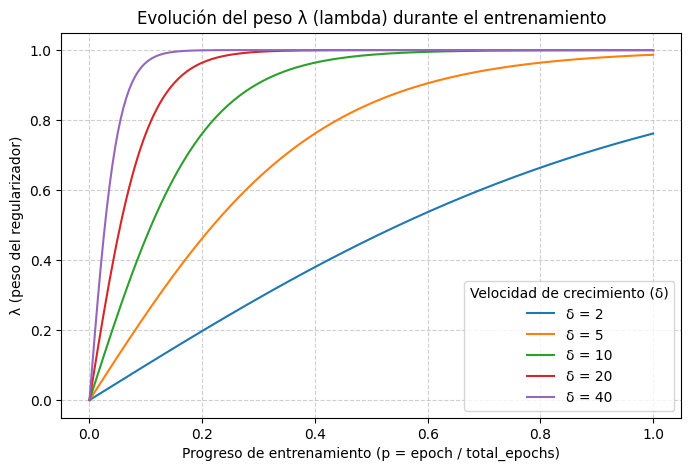

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_lambda(p, delta=10):
    """Crecimiento sigmoidal del peso regularizador."""
    return (1 - np.exp(-delta * p)) / (1 + np.exp(-delta * p))

# --- Configuración ---
deltas = [2, 5, 10, 20, 40]  # distintos niveles de crecimiento
p = np.linspace(0, 1, 200)   # progreso normalizado (epoch/total_epochs)

plt.figure(figsize=(8, 5))
for d in deltas:
    λ = get_lambda(p, delta=d)
    plt.plot(p, λ, label=f"δ = {d}")

plt.title("Evolución del peso λ (lambda) durante el entrenamiento")
plt.xlabel("Progreso de entrenamiento (p = epoch / total_epochs)")
plt.ylabel("λ (peso del regularizador)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Velocidad de crecimiento (δ)")
plt.show()

In [ ]:
EPOCHS = 100

In [ ]:
import numpy as np
import os
import scipy.io
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from tensorflow.keras.optimizers import Adam
from copy import deepcopy
from collections import defaultdict
import tensorflow as tf
import random


def train_L24O_cv(model_builder, X, y, sbjs, model_args, compile_args, folds, model_name='', delta=10, seed=42):
    all_fold_metrics = []
    total_histories = []
    models = {}  # <--- aquí se almacenarán todos los modelos entrenados por fold

    for fold, (train_subjects, test_subjects) in enumerate(folds):
        print(f"\n{'-'*60}")
        print(f"Fold {fold+1}/{len(folds)}  |  Test subjects: {test_subjects}")
        print(f"{'-'*60}")

        # --- Índices de entrenamiento y prueba ---
        train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        sbjs_test = [sbjs[i] for i in test_idx]

        # --- Reiniciar contexto de TensorFlow ---
        tf.keras.backend.clear_session()

        # --- Semillas reproducibles ---
        np.random.seed(seed + fold)
        random.seed(seed + fold)
        tf.random.set_seed(seed + fold)

        # --- Construcción del modelo ---
        model = model_builder(**model_args)
        optimizer = Adam(learning_rate=1e-3)
        compile_args_local = deepcopy(compile_args)
        compile_args_local['optimizer'] = optimizer
        model.compile(**compile_args_local)
        num_kernels = model_args["num_kernels"]

        dynamic_schedule = DynamicSchedule(
            total_epochs=100, optimizer=Adam(learning_rate=1e-3), delta=delta
        )

        # --- Entrenamiento ---
        history = model.fit(
            X_train,
            {
                'out_activation': y_train,
                'entropies_out': np.zeros((len(y_train), 4)),
                'kernel_weights_out': np.zeros((len(y_train), num_kernels))
            },
            validation_data=(X_test, {
                'out_activation': y_test,
                'entropies_out': np.zeros((len(y_test), 4)),
                'kernel_weights_out': np.zeros((len(y_test), num_kernels))
            }),
            epochs=100,
            batch_size=16,
            callbacks=[dynamic_schedule],
            verbose=0
        )

        total_histories.append(history)

        # --- Pesos convexos ---
        alpha = model.get_layer("convex_combination").get_weights()[0]
        print("Pesos convexos aprendidos (softmax):", tf.nn.softmax(alpha).numpy())
        print("Suma total:", tf.reduce_sum(tf.nn.softmax(alpha)).numpy())

        # --- Predicciones y métricas ---
        preds = model.predict(X_test)
        y_pred_probs = preds['out_activation']
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)

        fold_metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'kappa': cohen_kappa_score(y_true, y_pred),
            'auc': roc_auc_score(y_true, y_pred_probs[:, 1])
        }
        all_fold_metrics.append(fold_metrics)
        print(f"Fold {fold+1} Metrics: {fold_metrics}")

        # --- Guardar modelo de este fold ---
        models[fold] = model  # ✅ aquí se almacena el modelo

        # --- Accuracy por sujeto ---
        subject_correct = defaultdict(list)
        for yt, yp, sbj in zip(y_true, y_pred, sbjs_test):
            subject_correct[sbj].append(int(yt == yp))

        subject_accuracies = {sbj: np.mean(vals) for sbj, vals in subject_correct.items()}
        print("Accuracy promedio por sujeto:")
        for sbj in test_subjects:
            acc_sbj = subject_accuracies.get(sbj, None)
            if acc_sbj is not None:
                print(f"  {sbj}: {acc_sbj:.4f}")

    # --- Promedio global de métricas ---
    mean_metrics = {}
    for key in all_fold_metrics[0].keys():
        vals = [f[key] for f in all_fold_metrics]
        mean_metrics[f'mean_{key}'] = np.mean(vals)
        mean_metrics[f'std_{key}'] = np.std(vals)

    print("\nIndividual Fold Accuracies:")
    for i, f in enumerate(all_fold_metrics):
        print(f"  Fold {i+1}: {f['accuracy']:.4f}")

    return all_fold_metrics, models, total_histories  # ✅ ahora devuelve todos los modelos

In [13]:
from tensorflow.keras.losses import CategoricalCrossentropy, MeanSquaredError
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    "RenyiMutualInformation": RenyiMutualInformation
})

model_name = 'GMRRNet'
model_args = {
    'num_kernels': 3,
    'nb_classes': 2,
    'Chans': 19,
    'Samples': 512,
    'norm_rate': 0.1,
    'alpha': 2,
    'num_heads': 2,
    'intermediate_dim': 64
}

compile_args = {
    'optimizer': Adam(learning_rate=1e-3),
    'loss': {
        'out_activation': NormalizedBinaryCrossentropy(name="NormalizedBinaryCrossentropy"),
        'entropies_out': RenyiMutualInformation(C=19.0, name='MutualInfo'),
        'kernel_weights_out': 'mean_squared_error'
    },
    'loss_weights': {
        'out_activation': 0.5,  # Inicial
        'entropies_out': 0.5,
        'kernel_weights_out': 0.0
    },
    'metrics': {'out_activation': ['binary_accuracy', tf.keras.metrics.AUC(name="AUC")]}
    }

import tensorflow as tf
import numpy as np

class DynamicSchedule(tf.keras.callbacks.Callback):
    def __init__(self, total_epochs, optimizer, eta_0=1e-3, alpha=10, beta=0.75, delta=10):
        super().__init__()
        self.total_epochs = total_epochs
        self.eta_0 = eta_0
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.optimizer = optimizer
        self.lambda_val = 0.0

    def get_eta(self, epoch):
        p = epoch / self.total_epochs
        return self.eta_0 * (1 + self.alpha * p) ** (-self.beta)

    def get_lambda(self, epoch):
        p = epoch / self.total_epochs
        return 2 * (1 - np.exp(-self.delta * p)) / (1 + np.exp(-self.delta * p))

    def on_epoch_begin(self, epoch, logs=None):
        new_lr = self.get_eta(epoch)
        self.lambda_val = self.get_lambda(epoch)

        # ✅ Ajustar learning rate correctamente
        if hasattr(self.optimizer.learning_rate, "assign"):
            self.optimizer.learning_rate.assign(new_lr)
        else:
            tf.keras.backend.set_value(self.optimizer.learning_rate, new_lr)

        # ✅ Actualizar dinámicamente los pesos de pérdida SIN recompilar
        if hasattr(self.model, "loss_weights") and isinstance(self.model.loss_weights, dict):
            self.model.loss_weights["out_activation"] = 1.0
            self.model.loss_weights["entropies_out"] = self.lambda_val

        print(f"[Epoch {epoch+1}] LR={float(new_lr):.6f} | λ={self.lambda_val:.3f}")


I0000 00:00:1762383659.385604      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762383659.386221      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
results = {}

for i in range(1):
    result, models, total_histories = train_L24O_cv(GMRRNet, X, y, sbjs, model_args, compile_args, folds, model_name, delta=20)
    results[i]=result

In [15]:
import pickle

proj_weights_folds = {}
attention_scores_folds = {}
for i in range(5):
    loaded_model = models[i]
    encoder_layer = loaded_model.get_layer("transformer_encoder")
    
    projection_weights = encoder_layer.get_attention_weights()
    
    proj_weights_folds[f"{i+1}"] = projection_weights 

with open("proj_weights_folds.pkl", "wb") as f:
    pickle.dump(proj_weights_folds, f)

In [16]:
import pandas as pd

channel_names = ['Fz', 'Cz', 'Pz', 'C3', 'T3', 'C4', 'T4', 'Fp1', 'Fp2',
                 'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'T5', 'T6', 'O1', 'O2']

with open("/kaggle/working/proj_weights_folds.pkl", "rb") as f:
    new_data = pickle.load(f)

# Reconstruir rankings
channel_rankings = {}
for fold in sorted(new_data.keys()):
    fold_data = new_data[fold]
    matrices = [fold_data['query'], fold_data['key'], fold_data['value']]
    per_matrix_means = [np.abs(m).mean(axis=(1, 2)) for m in matrices]
    avg_importance = np.mean(per_matrix_means, axis=0)
    rankings = np.argsort(np.argsort(-avg_importance)) + 1
    channel_rankings[fold] = rankings

data = pd.DataFrame(channel_rankings)
data.columns = [f"Fold {i}" for i in range(1,6)]
data.index.name = "Channel"
data.index = channel_names

# Mostrar datos calculados
data.head()

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
Fz,16,6,17,7,18
Cz,4,19,7,10,3
Pz,14,9,16,15,15
C3,11,13,5,11,16
T3,1,17,10,5,6


In [17]:
fold_data["query"].shape

(19, 2, 9)

In [18]:
import numpy as np

def compute_channel_content_importance(Wq, Wk, Wv, use_abs=True):
    """
    Wq, Wk, Wv: numpy arrays de forma (C, H, d)
    return:
        M: matriz canal-canal (C,C)
        att_vec: importancia como "canal consultado"
        content_vec: importancia modulada por valores (aporte de contenido)
        ranking: índices ordenados de mayor a menor importancia
    """

    C, H, d = Wq.shape
    
    # 1) Matriz de interacción canal–canal promedio sobre cabezas
    M = np.zeros((C, C))
    for h in range(H):
        Qh = Wq[:,h,:]               # (C, d)
        Kh = Wk[:,h,:]               # (C, d)
        Mh = Qh @ Kh.T               # (C, C)
        if use_abs:
            Mh = np.abs(Mh)
        M += Mh
    M /= H

    # 2) Vector “consultado” = norma L2 por columna
    att_vec = np.linalg.norm(M, axis=0)  # (C,)

    # 3) Modulación por magnitud de V (importancia real del contenido)
    V_norm = np.linalg.norm(Wv, axis=(1,2))  # (C,)
    content_vec = att_vec * V_norm

    # normalizar vectores para fácil interpretación
    att_vec = att_vec / (att_vec.sum() + 1e-8)
    content_vec = content_vec / (content_vec.sum() + 1e-8)

    # 4) Ranking descendente
    ranking = np.argsort(content_vec)[::-1]

    return M, att_vec, content_vec, ranking


# ---- nueva parte: imprimir con nombres ----

for fold in proj_weights_folds.keys():
    print(f"\n===== {fold} =====")

    fold_data = proj_weights_folds[fold]
    Wq = fold_data["query"]
    Wk = fold_data["key"]
    Wv = fold_data["value"]

    M, att_vec, content_vec, ranking = compute_channel_content_importance(Wq, Wk, Wv)

    print("\nRanking de canales por aporte de contenido (mayor → menor):")
    for idx in ranking:
        print(f"{channel_names[idx]:>5s} (idx {idx:02d}): {content_vec[idx]:.4f}")


===== 1 =====

Ranking de canales por aporte de contenido (mayor → menor):
   P4 (idx 14): 0.0883
   C4 (idx 05): 0.0796
   Fz (idx 00): 0.0787
   T3 (idx 04): 0.0713
  Fp1 (idx 07): 0.0664
   F8 (idx 12): 0.0602
   Cz (idx 01): 0.0589
   C3 (idx 03): 0.0582
   F7 (idx 11): 0.0572
   T4 (idx 06): 0.0552
   F3 (idx 09): 0.0535
   T6 (idx 16): 0.0464
   F4 (idx 10): 0.0391
   Pz (idx 02): 0.0387
   P3 (idx 13): 0.0356
   T5 (idx 15): 0.0343
  Fp2 (idx 08): 0.0300
   O1 (idx 17): 0.0245
   O2 (idx 18): 0.0241

===== 2 =====

Ranking de canales por aporte de contenido (mayor → menor):
   C4 (idx 05): 0.0909
   Fz (idx 00): 0.0702
   F7 (idx 11): 0.0702
   P4 (idx 14): 0.0651
   F8 (idx 12): 0.0622
   Pz (idx 02): 0.0614
   F3 (idx 09): 0.0575
   P3 (idx 13): 0.0567
  Fp2 (idx 08): 0.0534
  Fp1 (idx 07): 0.0510
   T5 (idx 15): 0.0507
   T3 (idx 04): 0.0477
   O2 (idx 18): 0.0475
   T6 (idx 16): 0.0470
   C3 (idx 03): 0.0428
   O1 (idx 17): 0.0422
   Cz (idx 01): 0.0290
   F4 (idx 10): 0.02

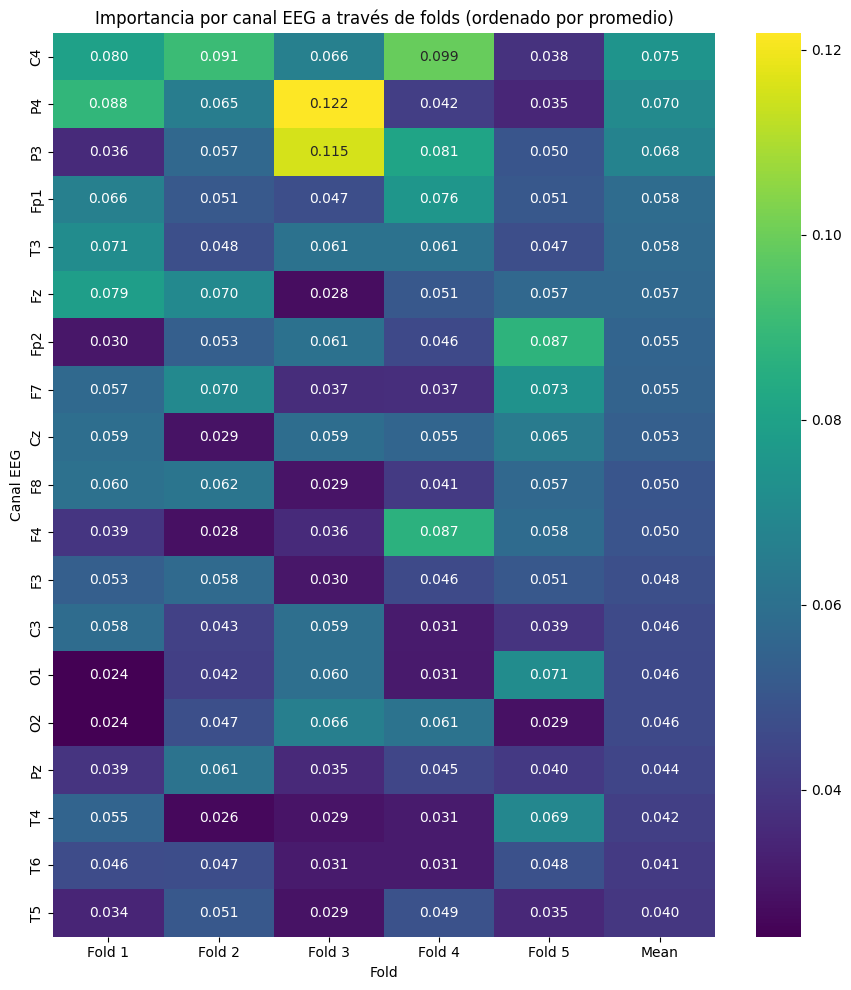


Tabla ordenada de importancia por canal:
       Fold 1    Fold 2    Fold 3    Fold 4    Fold 5      Mean
C4   0.079587  0.090857  0.066409  0.099115  0.038199  0.074833
P4   0.088344  0.065136  0.121843  0.041980  0.034734  0.070407
P3   0.035604  0.056736  0.115416  0.081257  0.050014  0.067805
Fp1  0.066363  0.050954  0.047031  0.075657  0.050585  0.058118
T3   0.071262  0.047709  0.060947  0.060934  0.047313  0.057633
Fz   0.078653  0.070194  0.027534  0.050588  0.056854  0.056765
Fp2  0.029986  0.053429  0.060545  0.045534  0.087437  0.055386
F7   0.057175  0.070189  0.036583  0.036969  0.073464  0.054876
Cz   0.058909  0.029044  0.058743  0.055486  0.064564  0.053349
F8   0.060188  0.062219  0.029102  0.040555  0.056717  0.049756
F4   0.039099  0.028323  0.035685  0.086711  0.057801  0.049524
F3   0.053481  0.057505  0.030202  0.046244  0.050640  0.047615
C3   0.058181  0.042848  0.059466  0.031337  0.038908  0.046148
O1   0.024459  0.042205  0.059576  0.030745  0.071135  0.04562

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C = len(channel_names)  # 19 canales
fold_names = list(proj_weights_folds.keys())
num_folds = len(fold_names)

# matriz canales x folds
importance_matrix = np.zeros((C, num_folds))

for f_idx, fold in enumerate(fold_names):
    fold_data = proj_weights_folds[fold]
    Wq = fold_data["query"]
    Wk = fold_data["key"]
    Wv = fold_data["value"]

    M, att_vec, content_vec, ranking = compute_channel_content_importance(Wq, Wk, Wv)

    importance_matrix[:, f_idx] = content_vec  # cada fila es un canal

# DataFrame base
df_heat = pd.DataFrame(
    importance_matrix,
    index=channel_names,
    columns=[f"Fold {i+1}" for i in range(num_folds)]
)

# Agregar columna de promedio
df_heat["Mean"] = df_heat.mean(axis=1)

# Ordenar canales según el promedio (descendente)
df_heat = df_heat.sort_values(by="Mean", ascending=False)

# Heatmap
plt.figure(figsize=(9, 10))
sns.heatmap(df_heat, cmap="viridis", annot=True, fmt=".3f")
plt.title("Importancia por canal EEG a través de folds (ordenado por promedio)")
plt.xlabel("Fold")
plt.ylabel("Canal EEG")
plt.tight_layout()
plt.show()

print("\nTabla ordenada de importancia por canal:")
print(df_heat)

In [20]:
data.loc['Fz']

Fold 1    16
Fold 2     6
Fold 3    17
Fold 4     7
Fold 5    18
Name: Fz, dtype: int64

In [21]:
sorted_channels = df_heat["Mean"].sort_values(ascending=False).index.tolist()

In [22]:
sorted_channels

['C4',
 'P4',
 'P3',
 'Fp1',
 'T3',
 'Fz',
 'Fp2',
 'F7',
 'Cz',
 'F8',
 'F4',
 'F3',
 'C3',
 'O1',
 'O2',
 'Pz',
 'T4',
 'T6',
 'T5']

# Ablación de canales

In [23]:
def ablate_channel(X, ch_idx, method="zero", mean=None, std=None, rng=None):
    """
    X: tensor (batch, channels, time)
    ch_idx: int (0-based)
    method: "zero" | "mean" | "gaussian" | "permute_batch" | "shuffle_time"
    mean,std: estadísticas del canal en TRAIN (tensors de shape (channels,) o floats por canal)
    rng: generador torch.Generator opcional
    """
    X_abl = X.copy()  # evita modificar el original

    if method == "zero":
        X_abl[:, ch_idx, :] = 0.0

    elif method == "mean":
        if mean is None:
            raise ValueError("Proporciona 'mean' (del set de entrenamiento) para método 'mean'.")
        X_abl[:, ch_idx, :] = mean[ch_idx]

    elif method == "gaussian":
        if mean is None or std is None:
            raise ValueError("Proporciona 'mean' y 'std' del canal para 'gaussian'.")
        noise = torch.randn((X.size(0), X.size(2)), generator=rng, device=X.device)
        X_abl[:, ch_idx, :] = mean[ch_idx] + std[ch_idx] * noise

    elif method == "permute_batch":
        # baraja el canal entre sujetos (rompe relación canal–etiqueta sin cambiar distribución)
        perm = torch.randperm(X.size(0), generator=rng, device=X.device)
        X_abl[:, ch_idx, :] = X[perm, ch_idx, :]

    elif method == "shuffle_time":
        # baraja el orden temporal dentro de cada ensayo para ese canal
        B, _, T = X.shape
        for b in range(B):
            perm_t = torch.randperm(T, generator=rng, device=X.device)
            X_abl[b, ch_idx, :] = X[b, ch_idx, perm_t]
    else:
        raise ValueError("Método no reconocido.")

    return X_abl

## Por ranking

In [24]:
# Ordenar canales por importancia media
sorted_channels = df_heat["Mean"].sort_values(ascending=False).index.tolist()

X, y, sbjs = get_segmented_data()
X_base = X.copy()   # copia limpia para referencia
accuracies = {}

# ✅ Paso 1: precisión sin ablación
acc_folds = []
for fold, (train_subjects, test_subjects) in enumerate(folds):
    model = models[fold]
    train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
    test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]

    X_test = X_base[test_idx]
    y_test = y[test_idx]

    preds = model.predict(X_test)
    y_pred_probs = preds['out_activation']
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc_folds.append(accuracy_score(y_true, y_pred))

print("No ablation:", acc_folds)
accuracies["No ablation"] = acc_folds

# ✅ Paso 2: ablación acumulativa según ranking
X_abl = X_base.copy()

for i, ch_name in enumerate(sorted_channels):
    idx = channel_names.index(ch_name)  # obtener índice del canal
    print(f"\n>>> Ablating channel #{i+1}: {ch_name} (idx {idx})")
    
    # ablación progresiva
    X_abl = ablate_channel(X_abl, idx)

    acc_folds = []
    for fold, (train_subjects, test_subjects) in enumerate(folds):
        model = models[fold]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]
        X_test_abl = X_abl[test_idx]
        y_test = y[test_idx]

        preds = model.predict(X_test_abl)
        y_pred_probs = preds['out_activation']
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)
        
        acc_folds.append(accuracy_score(y_true, y_pred))

    accuracies[ch_name] = acc_folds
    print(f"Acc after ablating {ch_name}: {acc_folds}")

with open("accuracies_ranking.pkl", "wb") as f:
    pickle.dump(accuracies, f)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
No ablation: [0.8888126286890872, 0.841726618705036, 0.9202488687782805, 0.8784825133372851, 0.8965094917330068]

>>> Ablating channel #1: C4 (idx 5)
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Acc after ablating C4: [0.8682223747426219, 0.8279376498800959, 0.877262443438914, 0.8067575577949022, 0.7985303123086344]

>>> Ablating channel #2: P4 (idx 14)
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Acc after ablating P4: [0.7083047357584077, 0.7565947242206235, 0.8557692307692307, 0.7806757557794902, 

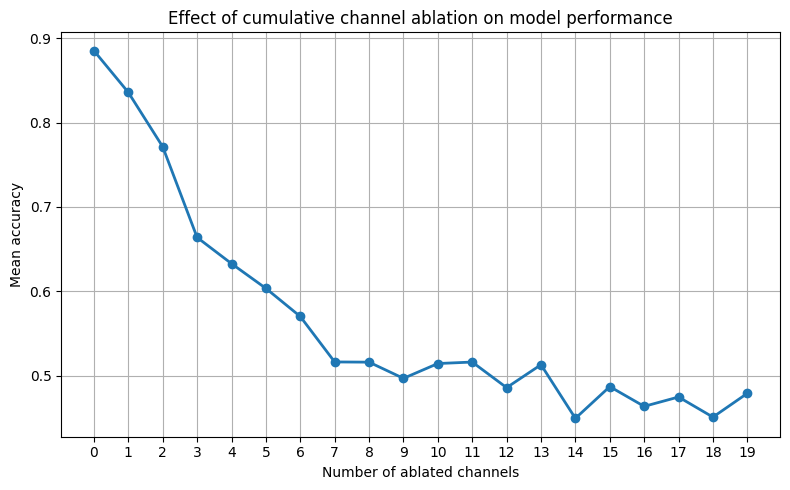

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Compute mean accuracy per ablation step
mean_acc = {channel: np.mean(acc) for channel, acc in accuracies.items()}

# X-axis: number of ablated channels
x = list(range(0, len(mean_acc) ))
y = list(mean_acc.values())

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', linewidth=2)
plt.xticks(x)
plt.xlabel("Number of ablated channels")
plt.ylabel("Mean accuracy")
plt.title("Effect of cumulative channel ablation on model performance")
plt.grid(True)
plt.tight_layout()
plt.savefig("ablation.pdf")
plt.show()

## aleatorio

In [26]:
X, y, sbjs = get_segmented_data()
y = np.array(y)  # Asegura indexación
X_ = X.copy()
random.seed(42)  # Para reproducibilidad

# Crear orden aleatorio de índices de canales
n_channels = len(channel_names)
random_indices = random.sample(range(n_channels), n_channels)
random_channels = [channel_names[i] for i in random_indices]

accuracies_random = {}
accuracies_random["No ablation"] = []  # Accuracy sin ablación

# 🔹 Evaluar precisión sin ablación
acc_folds = []
for fold, (train_subjects, test_subjects) in enumerate(folds):
    model = models[fold]
    train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
    test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]
    
    X_test = X_[test_idx]
    y_test = y[test_idx]

    # --- Predicciones y métricas ---
    preds = model.predict(X_test)
    y_pred_probs = preds['out_activation']
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_true, y_pred)
    acc_folds.append(acc)

accuracies_random["No ablation"] = acc_folds

# 🔹 Ablación acumulativa de canales aleatorios
for i, idx in enumerate(random_indices):
    X_ = ablate_channel(X_, idx)
    acc_folds = []

    for fold, (train_subjects, test_subjects) in enumerate(folds):
        model = models[fold]
        train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]
        
        X_test_abl = X_[test_idx]
        y_test = y[test_idx]

        # --- Predicciones y métricas ---
        preds = model.predict(X_test_abl)
        y_pred_probs = preds['out_activation']
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)
        acc = accuracy_score(y_true, y_pred)
        acc_folds.append(acc)

    abl_channels = ["No ablation"] + [channel_names[i] for i in random_indices[:i+1]]
    print(f"Ablated (random): {abl_channels[-1]}")
    accuracies_random[random_channels[i]] = acc_folds

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Ablated (random): C3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Ablated (random): Fz
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Ablated (random): Fp2
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


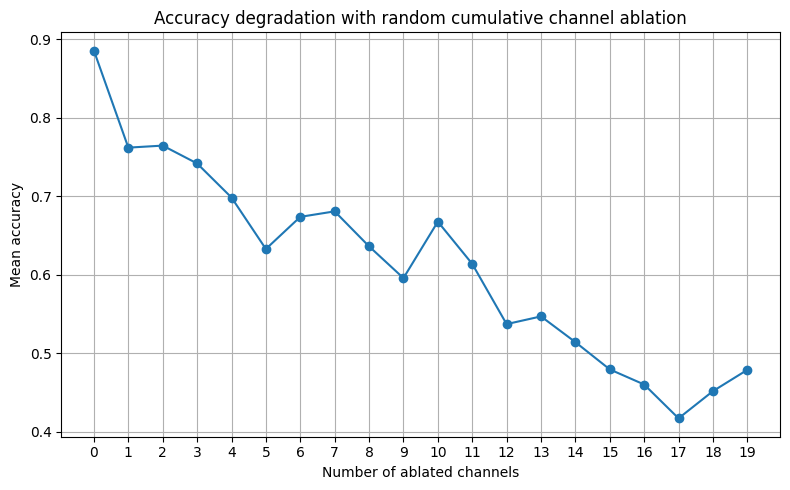

In [27]:
mean_acc_random = {k: np.mean(v) for k, v in accuracies_random.items()}

x_labels = list(mean_acc_random.keys())
x = list(range(len(x_labels)))
y = list(mean_acc_random.values())

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-')
plt.xticks(x)
plt.xlabel("Number of ablated channels")
plt.ylabel("Mean accuracy")
plt.title("Accuracy degradation with random cumulative channel ablation")
plt.grid(True)
plt.tight_layout()
plt.savefig("ablation_random.pdf")
plt.show()

Probando con varias semillas

In [28]:
import numpy as np
from sklearn.metrics import accuracy_score

X, y, sbjs = get_segmented_data()
y = np.array(y)  # Asegura indexación

NUM_SEEDS = 50  # puedes poner 50 si quieres mayor robustez
random_results = []

def random_ablation_order(channel_names, seed):
    rng = np.random.default_rng(seed)
    return rng.permutation(channel_names).tolist()

# baseline accuracy
baseline = np.mean(accuracies["No ablation"])
print("Baseline accuracy:", baseline)

for seed in range(NUM_SEEDS):
    print(f"\n=== Random run {seed} ===")
    X_abl = X_base.copy()
    random_order = random_ablation_order(channel_names, seed)
    
    seed_accs = [baseline]  # accuracy sin ablación
    
    for ch_name in random_order:
        idx = channel_names.index(ch_name)
        X_abl = ablate_channel(X_abl, idx)

        acc_folds = []
        for fold, (train_subjects, test_subjects) in enumerate(folds):
            model = models[fold]
            train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
            test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]
            X_test_abl = X_abl[test_idx]
            y_test = y[test_idx]

            preds = model.predict(X_test_abl)
            y_pred_probs = preds["out_activation"]
            y_pred = np.argmax(y_pred_probs, axis=1)
            y_true = np.argmax(y_test, axis=1)
            acc_folds.append(accuracy_score(y_true, y_pred))

        seed_accs.append(np.mean(acc_folds))

    random_results.append(seed_accs)

random_results = np.array(random_results)  # shape = (num_seeds, num_channels+1)

Baseline accuracy: 0.8851560242485391

=== Random run 0 ===
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/5

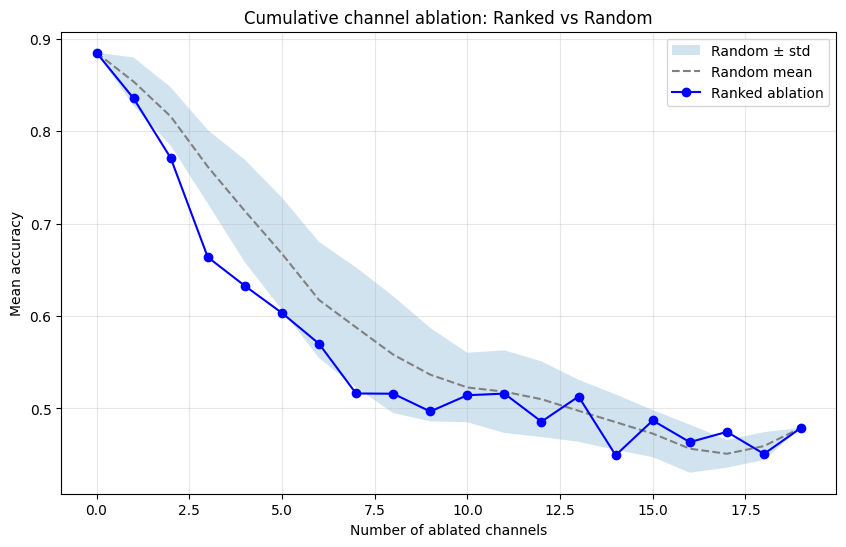

In [29]:
import matplotlib.pyplot as plt

n = random_results.shape[1]  # number of ablation steps
x = np.arange(n)

mean_random = random_results.mean(axis=0)
std_random = random_results.std(axis=0)

# sorted (tu curva buena)
sorted_curve = [np.mean(accuracies["No ablation"])] + \
                [np.mean(accuracies[ch]) for ch in sorted_channels]

plt.figure(figsize=(10,6))

# random band
plt.fill_between(x,
                 mean_random - std_random,
                 mean_random + std_random,
                 alpha=0.2, label="Random ± std")

plt.plot(x, mean_random, label="Random mean", color="gray", linestyle='--')

# sorted curve
plt.plot(x, sorted_curve, marker="o", label="Ranked ablation", color="blue")

plt.title("Cumulative channel ablation: Ranked vs Random")
plt.xlabel("Number of ablated channels")
plt.ylabel("Mean accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [30]:
from scipy.stats import ttest_ind

# ejemplo: comparar las 5 primeras ablaciones
t_stat, p_value = ttest_ind(random_results[:,1:6].mean(axis=1), [sorted_curve[i] for i in range(1,6)])
print("p-value primeros 5 pasos:", p_value)


p-value primeros 5 pasos: 0.00272277344545223
